In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage
import glob
import tqdm
import pickle
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
bench_dict = {"93,98,99":"/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0090_m6Afinal/pileup.genomic.pkl",
              "93,98":"/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A-20241107-154847-14-203000-token_normalise_ver161024_ON0090_m6Afinal/pileup_strid.genomic.pkl",
              "93,98,99,118":"/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241125-221455-22-492000-token_normalise_ver161024_ON0090_m6Afinal/pileup_strid.genomic.pkl",
              "99,118":"/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver161024_ON0090_m6Afinal/pileup_strid.genomic.pkl"}

bench_dict = {k: pd.read_pickle(v) for k, v in bench_dict.items()}

print(bench_dict)

{'93,98,99':                        genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         1  0.009356   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         1 -0.000000   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         1  0.007684   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         1 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         1  0.007402   
...                          ...         ...     ...       ...       ...   
chrX:-:9760794    chrX:-:9760794      GPR143    True         1  0.000000   
chrX:-:9760797    chrX:-:9760797      GPR143    True         1  0.000000   
chrX:-:9760808    chrX:-:9760808      GPR143    True         1  0.000000   
chrX:-:9760817    chrX:-:9760817      GPR143    True         1  0.000000   
chrX:-:9760823    chrX:-:9760823      GPR143    True         1  0.000000   

In [3]:
label_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/BaeklabFinal.Genome.v2Genomic.GP3.depth5_None.twm6astrict.agg.pkl")
label_df.rename(columns = {"m6A_level": "dom_label"}, inplace = True)

In [4]:
bench_dict = {k: v.reset_index(drop=True).merge(label_df, on="genome_id", how = "right") for k, v in bench_dict.items()}

In [5]:
bench_dict = {k: v.fillna(0) for k, v in bench_dict.items()}

In [23]:
def process_df(path):
    df = pd.read_pickle(path).reset_index(drop=True).merge(label_df, on="genome_id", how = "right").fillna(0)
    return df

In [24]:
bench_dict["93,98,99,118-v2"] = process_df("/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v3B-m6A_ON0118-20241125-221430-16-368000-token_normalise_ver161024_ON0090_m6Afinal/pileup_strid.genomic.pkl")

In [25]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

In [26]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 28, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 10})
plt.rcParams.update({"axes.prop_cycle": plt.cycler("color", ["royalblue", "tomato", "forestgreen", "darkgoldenrod", "darkorchid"])})

In [27]:
bench_dict_filtered = {k: v[(v["depth"] >= 20) & (v["label"] >= 0) & ((v["label"] == 0)|(v["dom_label"] > 0.1))].copy() for k, v in bench_dict.items()}
for k, v in bench_dict_filtered.items():
    v["pm6a"] = v["pm6a"] * (v["count_all"] >= 20)

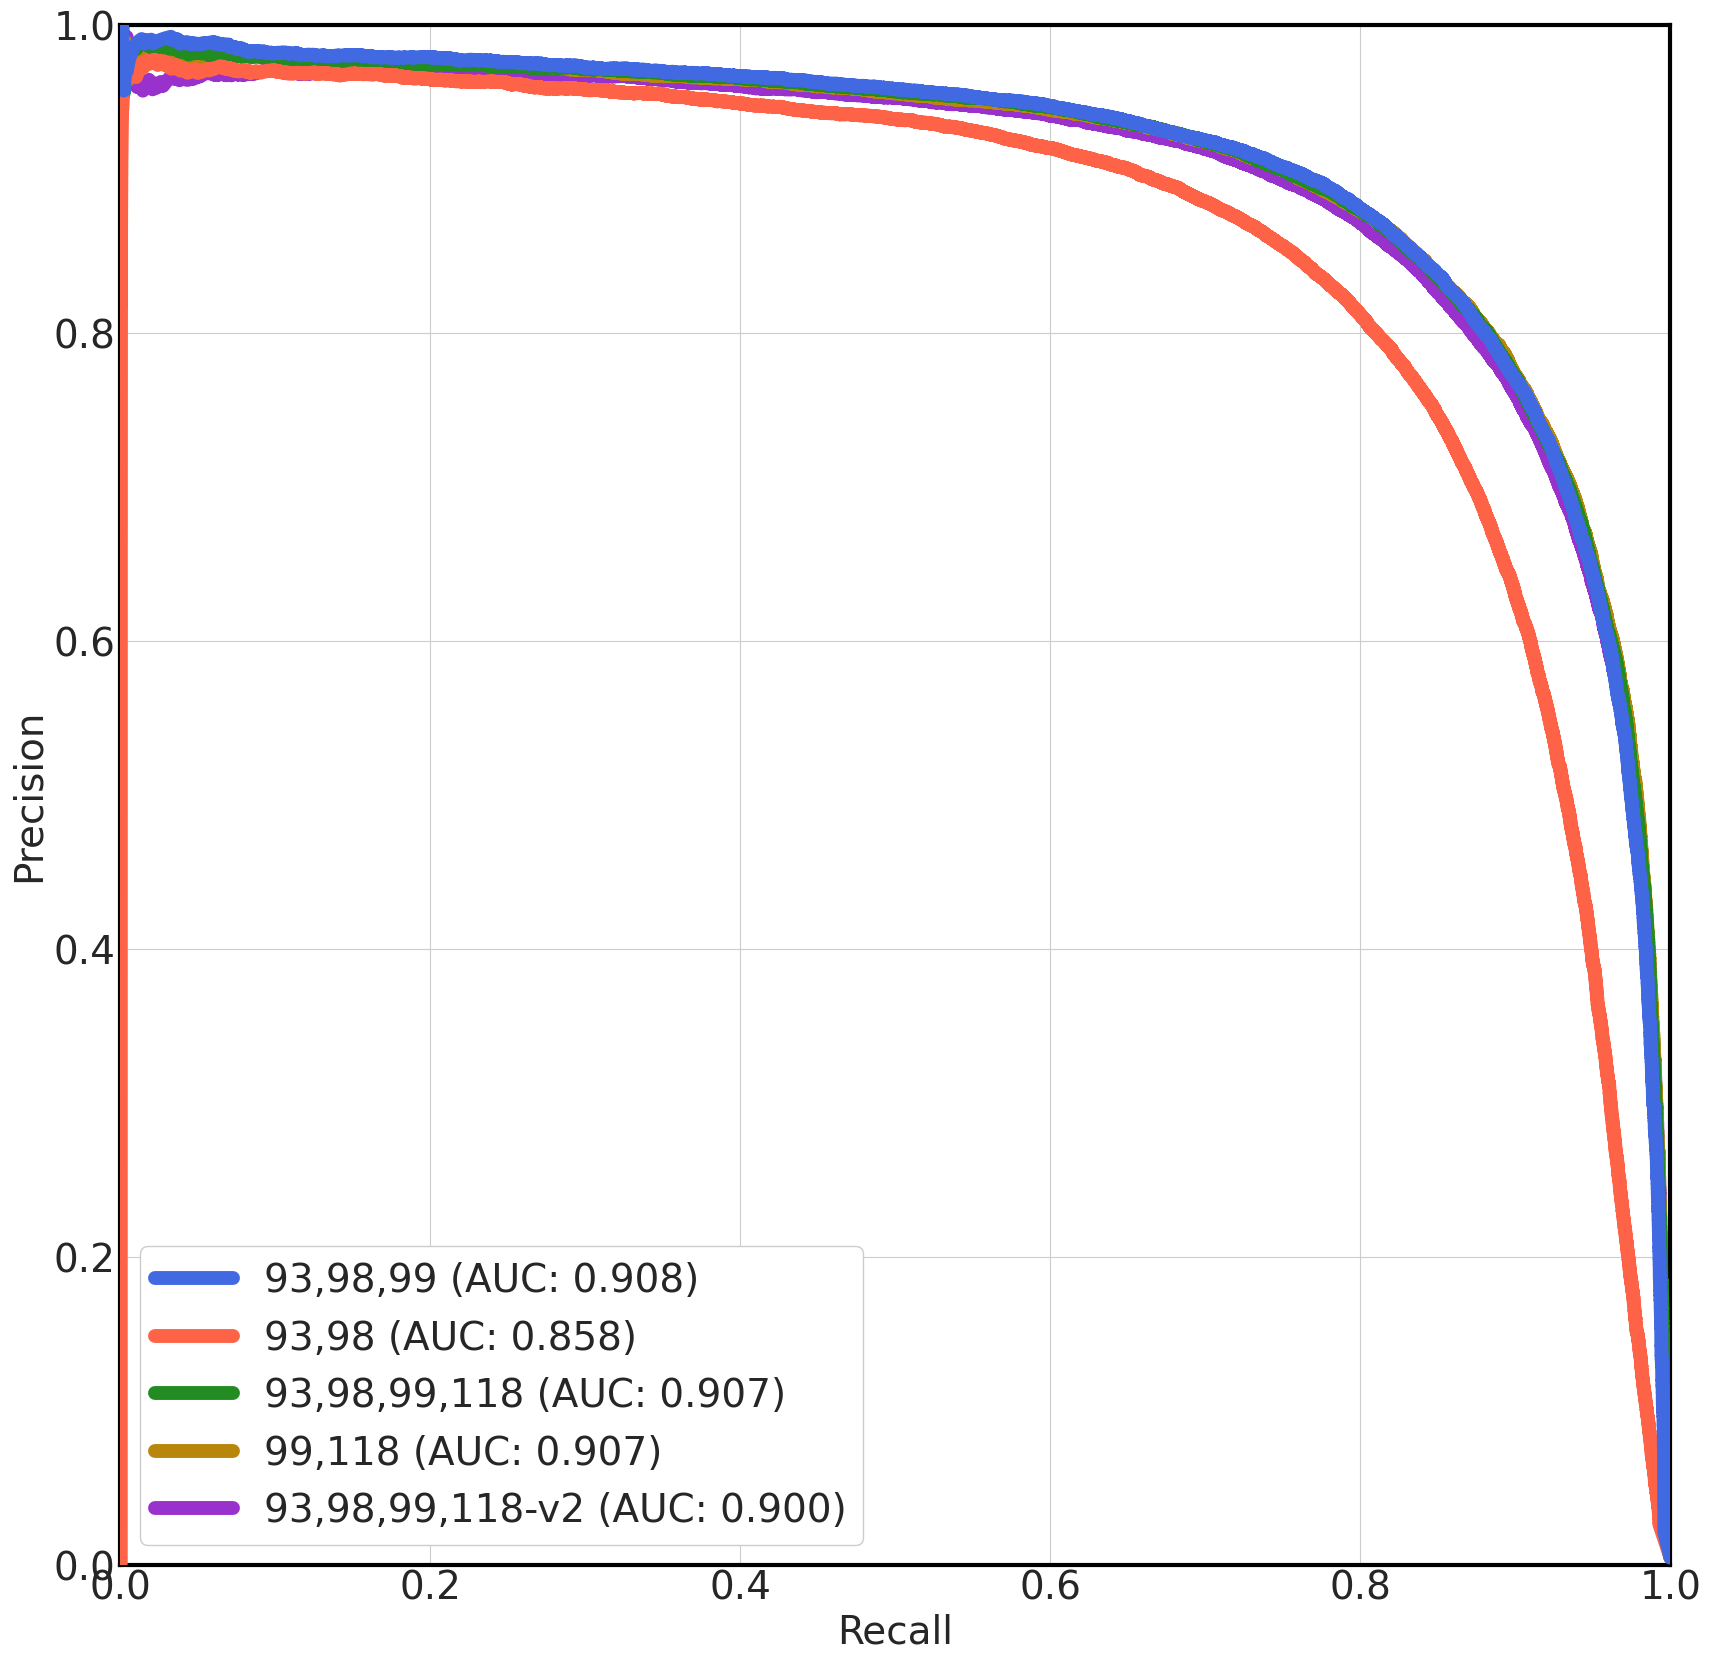

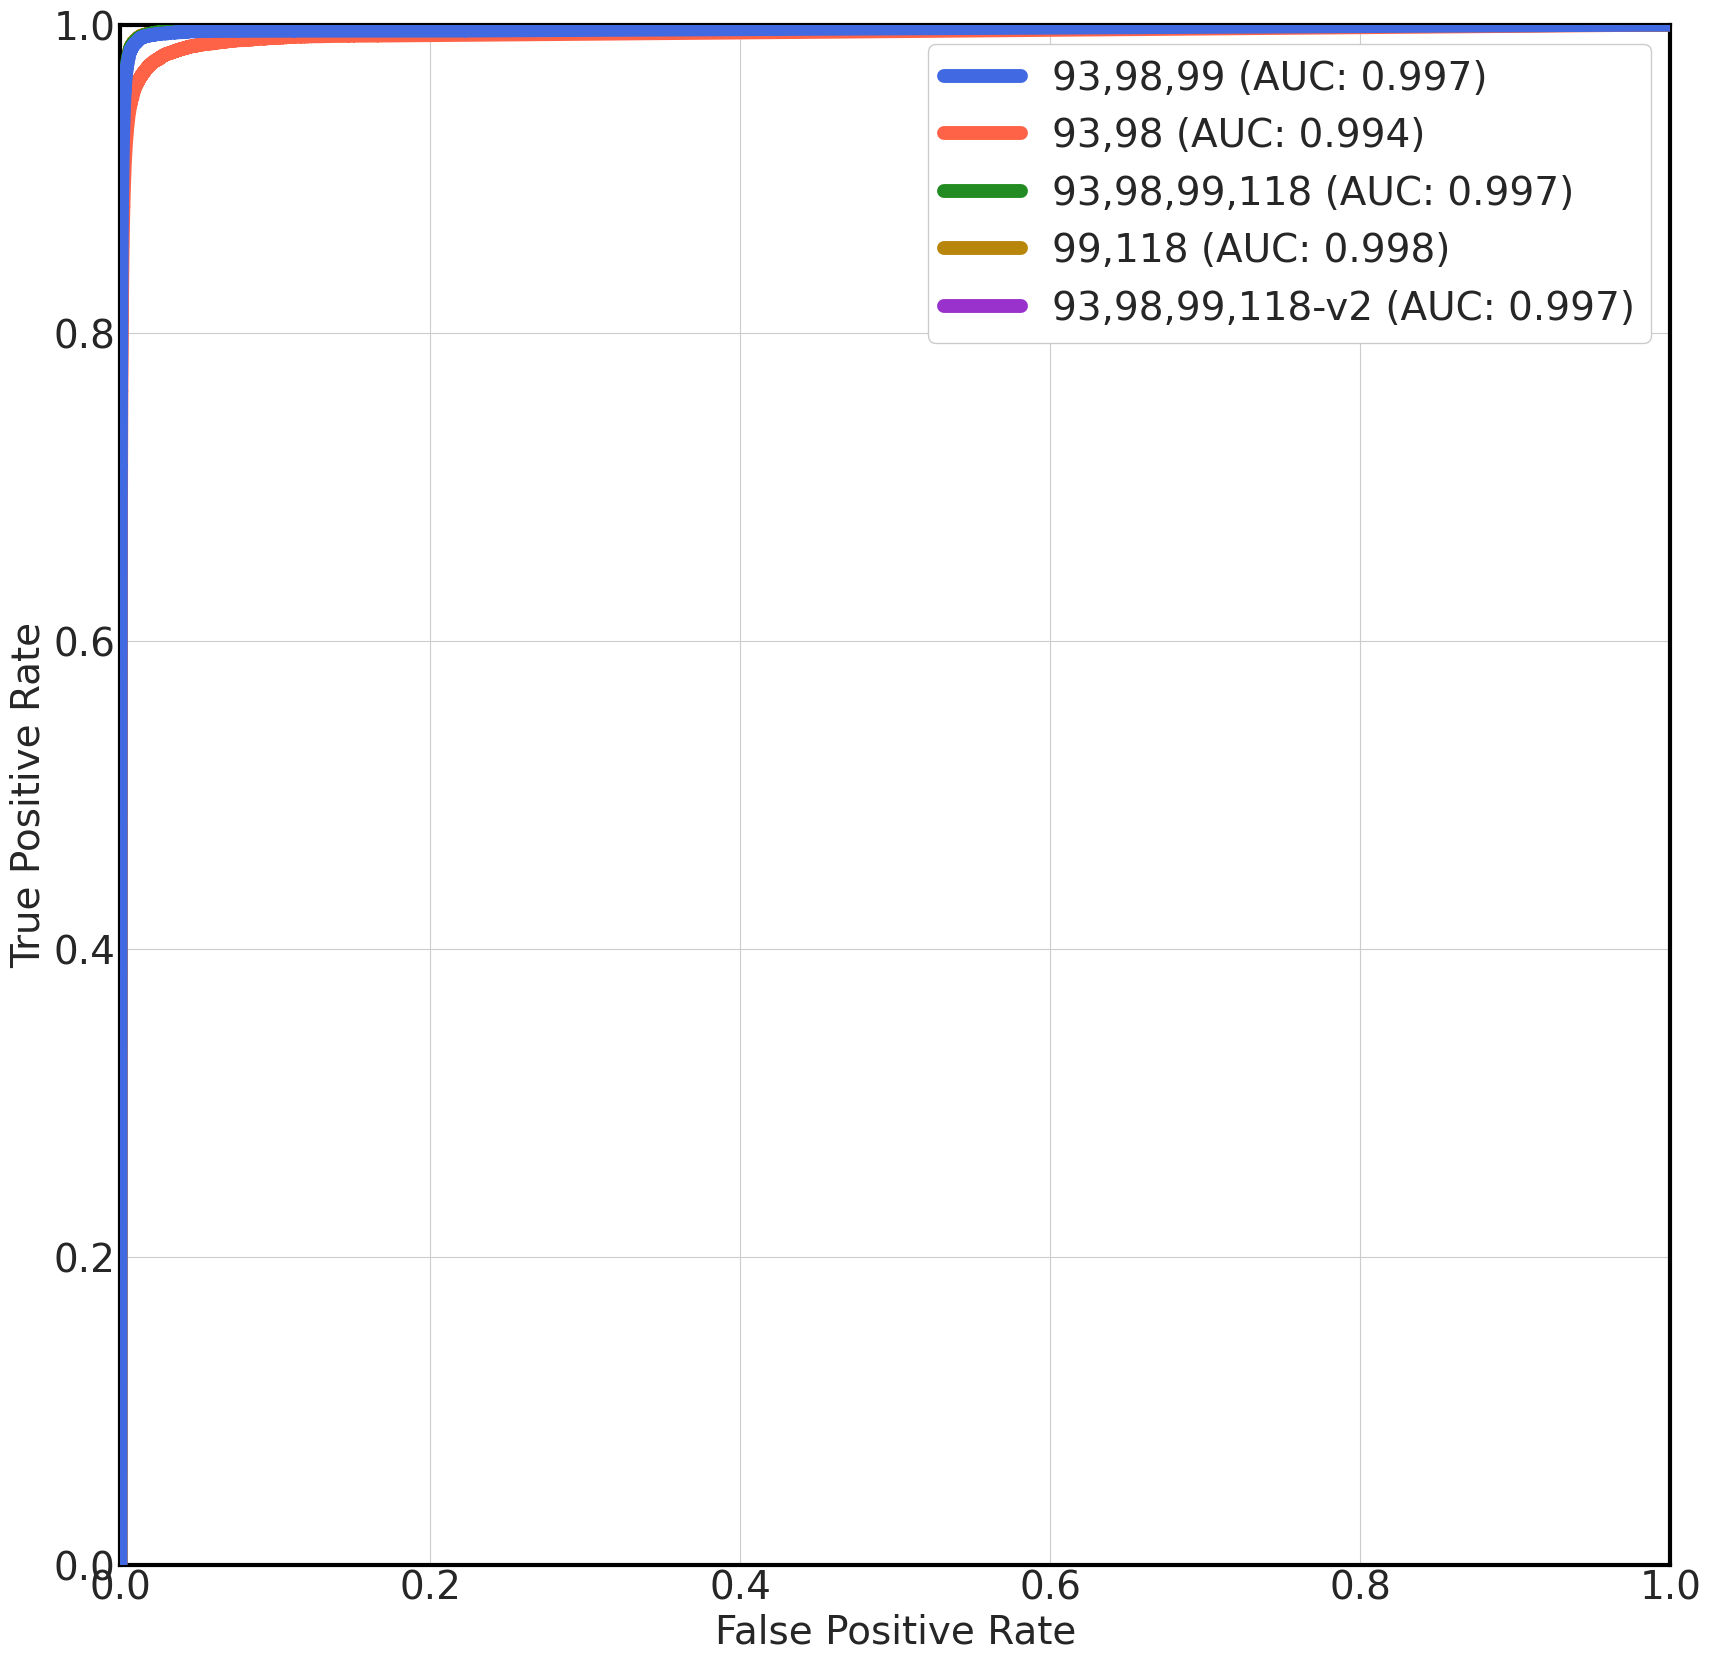

In [28]:
## Plot PR
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

for i, (k, v) in enumerate(bench_dict_filtered.items()):
    precision, recall, _ = precision_recall_curve(v["label"], v["pm6a"])
    auc_score = auc(recall, precision)
    ax.plot(recall, precision, label=f"{k} (AUC: {auc_score:.3f})", zorder=len(bench_dict_filtered) - i)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))


for i, (k, v) in enumerate(bench_dict_filtered.items()):
    fpr, tpr, _ = roc_curve(v["label"], v["pm6a"])
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{k} (AUC: {auc_score:.3f})", zorder=len(bench_dict_filtered) - i)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.show()


In [11]:
from scipy import stats

In [12]:
def get_density(x,y, sample=1000, bw_method= 0.2):
    values = np.stack([x, y], axis=0)
    sampled = values
    sampled = sampled[:, np.random.choice(sampled.shape[1], sample, replace=False)]
    kernel = stats.gaussian_kde(sampled, bw_method=bw_method)
    density = kernel(values)
    density = np.clip(density, None, np.percentile(density[x>0], 99))
    return density

In [21]:
from scipy import stats

def plot_scatter(ax, df, x = "m6A_level", y = "dom", alpha=0.5, s = 30, bw_method = 0.2, sample = 1000):
    plt.style.use('default')
    plt.style.use('seaborn-v0_8-white')
    plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
    density = get_density(df[x], df[y], sample=sample, bw_method=bw_method)
    sns.scatterplot(x=df[x], y=df[y], ax=ax, c=density,
                    cmap=sns.color_palette("flare_r", as_cmap=True), s=s, legend=False, linewidth=0, alpha = alpha)
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.set_xlabel("DoM (GLORI)")
    ax.set_ylabel("DoM (AIRNA)")
    r2 = stats.pearsonr(df[x], df[y])[0]**2
    rho2 = stats.spearmanr(df[x], df[y])[0]**2
    ax.text(0.05,0.95, f"R2 ={r2:.3f}\nRho2={rho2:.3f}\nn={len(df):,}", fontsize=24, transform=ax.transAxes, ha = "left", va = "top", bbox=dict(facecolor='white', alpha=1.0, edgecolor='black', boxstyle='round,pad=0.5'))

In [14]:
def dom_threshold(df):
    return np.log10(0.02)*(df["dom"]) > df["logsum_1_p_pos"]/df["count_all"]

In [17]:
bench_dict_filtered = {k: v.copy() for k, v in bench_dict.items()}
for k, v in bench_dict_filtered.items():
    v["dom_threshold"] = dom_threshold(v)
    v = v[(v["count_all"] >= 20) & v["dom_threshold"]]
    bench_dict_filtered[k] = v

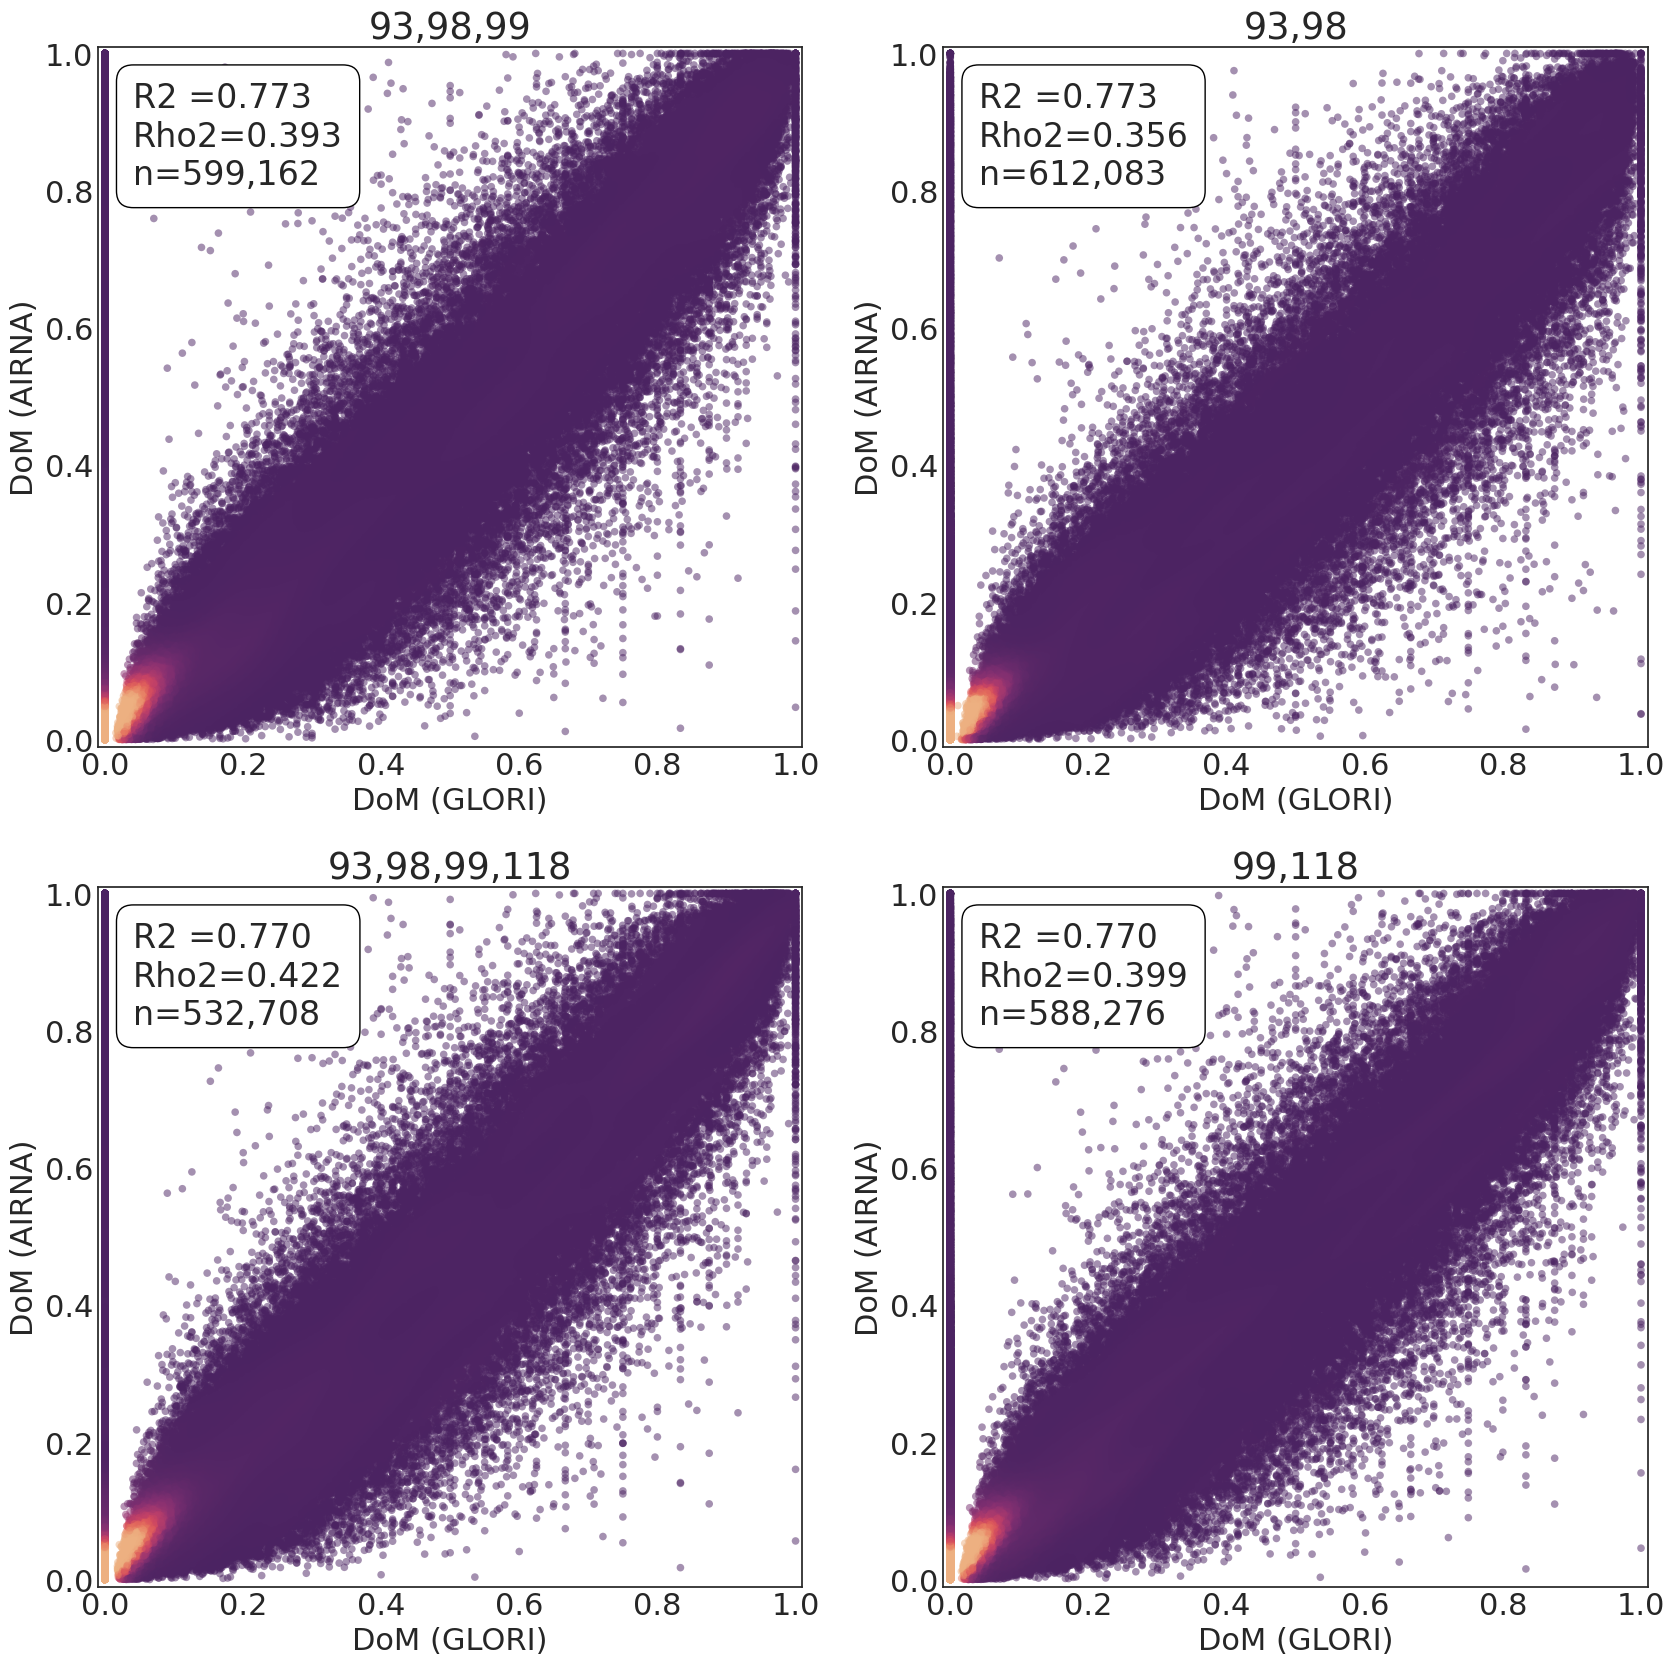

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
for i, (k, v) in enumerate(bench_dict_filtered.items()):
    plot_scatter(axes.flatten()[i], v, x="dom_label", y="dom", alpha=0.5, s=30, bw_method=0.2, sample=1000)
    axes.flatten()[i].set_title(k)
plt.show()
